In [61]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.style.use("seaborn-v0_8-colorblind")

matplotlib.rcParams.update({'font.size': 24})
matplotlib.rcParams.update({'font.weight': "normal"})

In [62]:
def results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        if "e" in config.keys():
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "method", "e", "b", "test_mae"])

def read_file(dataset, seeds=[0, 1, 2, 3, 4]):
    results_df = pd.DataFrame()
    for s in seeds:
        with open(dataset + "/MetaMF_s" + str(s) +".baseline", "rb") as f:
            meta_bsl = pkl.load(f)
            meta_bsl_df = results_to_df(meta_bsl, dataset, "baseline", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".baseline", "rb") as f:
            nometa_bsl = pkl.load(f)
            nometa_bsl_df = results_to_df(nometa_bsl, dataset, "baseline", "NoMetaMF")
            
        with open(dataset + "/MetaMF_s" + str(s) +".random_dp", "rb") as f:
            meta_rand = pkl.load(f)
            meta_rand_df = results_to_df(meta_rand, dataset, "random_dp", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".random_dp", "rb") as f:
            nometa_rand = pkl.load(f)
            nometa_rand_df = results_to_df(nometa_rand, dataset, "random_dp", "NoMetaMF")
            
        with open(dataset + "/MetaMF_s" + str(s) +".ister_dp", "rb") as f:
            meta_ister = pkl.load(f)
            meta_ister_df = results_to_df(meta_ister, dataset, "ister_dp", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".ister_dp", "rb") as f:
            nometa_ister = pkl.load(f)
            nometa_ister_df = results_to_df(nometa_ister, dataset, "ister_dp", "NoMetaMF")
            
        results_per_seed_df = pd.concat([meta_bsl_df, nometa_bsl_df, meta_rand_df, nometa_rand_df, meta_ister_df, nometa_ister_df])
        results_df = pd.concat([results_df, results_per_seed_df])
    return results_df

def add_baseline(results_df, method, e):
    bsl = results_df[(results_df["method"] == "baseline") & ((results_df["e"] == np.inf) | (results_df["e"] == e))]
    method = results_df[(results_df["method"] == method) & (results_df["e"] == e)]
    method = pd.concat([bsl, method]).sort_values(by=["e", "b"], ascending=False)
    return method

In [63]:
ml1m_results_df = read_file("ml1m", seeds=[0, 1, 2, 3, 4])
ml1m_stdev_df = ml1m_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].std().reset_index()
ml1m_results_df = ml1m_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].mean().reset_index()
ml1m_results_df = ml1m_results_df.merge(ml1m_stdev_df, left_on=["recsys", "method", "e", "b"], right_on=["recsys", "method", "e", "b"])
ml1m_results_df.rename(columns={"test_mae_x": "test_mae", "test_mae_y": "stdev"}, inplace=True)
ml1m_results_df.head()

,recsys,method,e,b,test_mae,stdev
0,MetaMF,baseline,0.1,0.0,0.756765,0.003085
1,MetaMF,baseline,1.0,0.0,0.721618,0.001059
2,MetaMF,baseline,2.0,0.0,0.702737,0.002271
3,MetaMF,baseline,3.0,0.0,0.698506,0.011612
4,MetaMF,baseline,inf,1.0,0.685652,0.002051


In [64]:
bx_results_df = read_file("bx", seeds=[0, 1, 2, 3, 4])
bx_stdev_df = bx_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].std().reset_index()
bx_results_df = bx_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].mean().reset_index()
bx_results_df = bx_results_df.merge(bx_stdev_df, left_on=["recsys", "method", "e", "b"], right_on=["recsys", "method", "e", "b"])
bx_results_df.rename(columns={"test_mae_x": "test_mae", "test_mae_y": "stdev"}, inplace=True)
bx_results_df.head()

,recsys,method,e,b,test_mae,stdev
0,MetaMF,baseline,0.1,0.0,1.503924,0.016242
1,MetaMF,baseline,1.0,0.0,0.904995,0.006012
2,MetaMF,baseline,2.0,0.0,0.738709,0.006689
3,MetaMF,baseline,3.0,0.0,1.182116,0.001687
4,MetaMF,baseline,inf,1.0,1.178874,0.002718


# RQ1: Does Meta Learning improve the accuracy-privacy trade-off? (MetaMF vs. NoMetaMF)

## relative change

In [ ]:
%matplotlib inline

In [ ]:
plt.figure(figsize=(8, 6))

meta = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 0)]
bsl = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
plt.plot(meta["e"], 100*(meta["test_mae"] - bsl) / bsl, label=r"$MetaMF_{DP}$", c="C1")

nometa = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 0)]
bsl = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
plt.plot(nometa["e"], 100*(nometa["test_mae"] - bsl) / bsl, label=r"$NoMetaMF_{DP}$", c="C1", linestyle="dashed")

plt.gca().invert_xaxis()
plt.legend()
plt.xlabel(r"Privacy Budget $\epsilon$")
plt.ylabel(r"$\Delta MAE$ in $\%$")
plt.tight_layout()
plt.savefig("figures/ml1m_mae.png", dpi=300)



plt.figure(figsize=(8, 6))

meta = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 0)]
bsl = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
plt.plot(meta["e"], 100*(meta["test_mae"] - bsl) / bsl, label=r"$MetaMF_{DP}$", c="C1")

nometa = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 0)]
bsl = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
plt.plot(nometa["e"], 100*(nometa["test_mae"] - bsl) / bsl, label=r"$NoMetaMF_{DP}$", c="C1", linestyle="dashed")

plt.gca().invert_xaxis()
plt.legend()
plt.xlabel(r"Privacy Budget $\epsilon$")
plt.ylabel(r"$\Delta MAE$ in $\%$")
plt.tight_layout()
plt.savefig("figures/bx_mae.png", dpi=300)


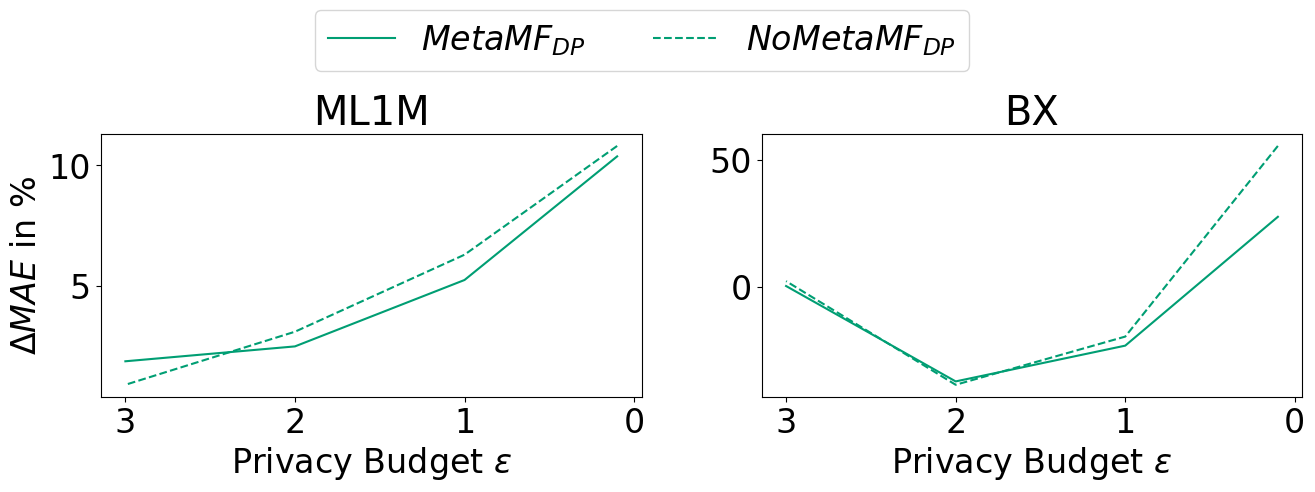

In [85]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------ LEFT: ML1M ------------------
ax = axes[0]

meta = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 0)]
bsl = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
l1, = ax.plot(meta["e"], 100*(meta["test_mae"] - bsl) / bsl,
              label=r"$MetaMF_{DP}$", c="C1")

nometa = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 0)]
bsl = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
l2, = ax.plot(nometa["e"], 100*(nometa["test_mae"] - bsl) / bsl,
              label=r"$NoMetaMF_{DP}$", c="C1", linestyle="dashed")

ax.invert_xaxis()
ax.set_title("ML1M")
ax.set_xlabel(r"Privacy Budget $\epsilon$")
ax.set_ylabel(r"$\Delta MAE$ in $\%$")


# ------------------ RIGHT: BX ------------------
ax = axes[1]

meta = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 0)]
bsl = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
ax.plot(meta["e"], 100*(meta["test_mae"] - bsl) / bsl,
        c="C1")

nometa = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 0)]
bsl = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
ax.plot(nometa["e"], 100*(nometa["test_mae"] - bsl) / bsl,
        c="C1", linestyle="dashed")

ax.invert_xaxis()
ax.set_title("BX")
ax.set_xlabel(r"Privacy Budget $\epsilon$")


# ------------------ SHARED LEGEND ------------------
fig.legend([l1, l2],
           [l.get_label() for l in [l1, l2]],
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.05))

# leave space for legend
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("figures/combined_mae.png", dpi=300, bbox_inches="tight")
plt.show()

## absolute values

In [ ]:
plt.figure()
meta = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 0)]
plt.plot(meta["e"], meta["test_mae"], label=r"$Full^{Meta}_{DP}$", c="C1")
nometa = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 0)]
plt.plot(nometa["e"], nometa["test_mae"], label=r"$Full_{DP}$", c="C1", linestyle="dashed")
plt.gca().invert_xaxis()
#plt.ylim([0, 1.3])
plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel("MAE")
plt.show()

plt.figure()
meta = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 0)]
plt.plot(meta["e"], meta["test_mae"], label=r"$Full^{Meta}_{DP}$", c="C1")
#plt.errorbar(meta["e"], meta["test_mae"], meta["stdev"], label=r"$Full^{Meta}_{DP}$", c="C1")
nometa = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 0)]
plt.plot(nometa["e"], nometa["test_mae"], label=r"$Full_{DP}$", c="C1", linestyle="dashed")
#plt.errorbar(nometa["e"], nometa["test_mae"], nometa["stdev"], label=r"$Full_{DP}$", c="C1", linestyle="dashed")
plt.gca().invert_xaxis()
#plt.ylim([0, 1.3])
plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel("MAE")
plt.show()

In [ ]:
bsl = ml1m_results_df[(ml1m_results_df["b"] == 1) & (ml1m_results_df["recsys"] == "MetaMF")]["test_mae"].values
print(bsl)
df = ml1m_results_df[(ml1m_results_df["b"] == 0) & (ml1m_results_df["recsys"] == "MetaMF")]
df["rel_mae"] = 100*(df["test_mae"] - bsl) / bsl
print(df)

bsl = ml1m_results_df[(ml1m_results_df["b"] == 1) & (ml1m_results_df["recsys"] == "NoMetaMF")]["test_mae"].values
print(bsl)
df = ml1m_results_df[(ml1m_results_df["b"] == 0) & (ml1m_results_df["recsys"] == "NoMetaMF")]
df["rel_mae"] = 100*(df["test_mae"] - bsl) / bsl
print(df)

In [ ]:
bsl = bx_results_df[(bx_results_df["b"] == 1) & (bx_results_df["recsys"] == "MetaMF")]["test_mae"].values
print(bsl)
df = bx_results_df[(bx_results_df["b"] == 0) & (bx_results_df["recsys"] == "MetaMF")]
df["rel_mae"] = 100*(df["test_mae"] - bsl) / bsl
print(df)

bsl = bx_results_df[(bx_results_df["b"] == 1) & (bx_results_df["recsys"] == "NoMetaMF")]["test_mae"].values
print(bsl)
df = bx_results_df[(bx_results_df["b"] == 0) & (bx_results_df["recsys"] == "NoMetaMF")]
df["rel_mae"] = 100*(df["test_mae"] - bsl) / bsl
print(df)

# RQ2: How can sampling improve the trade-off further?

## relative values

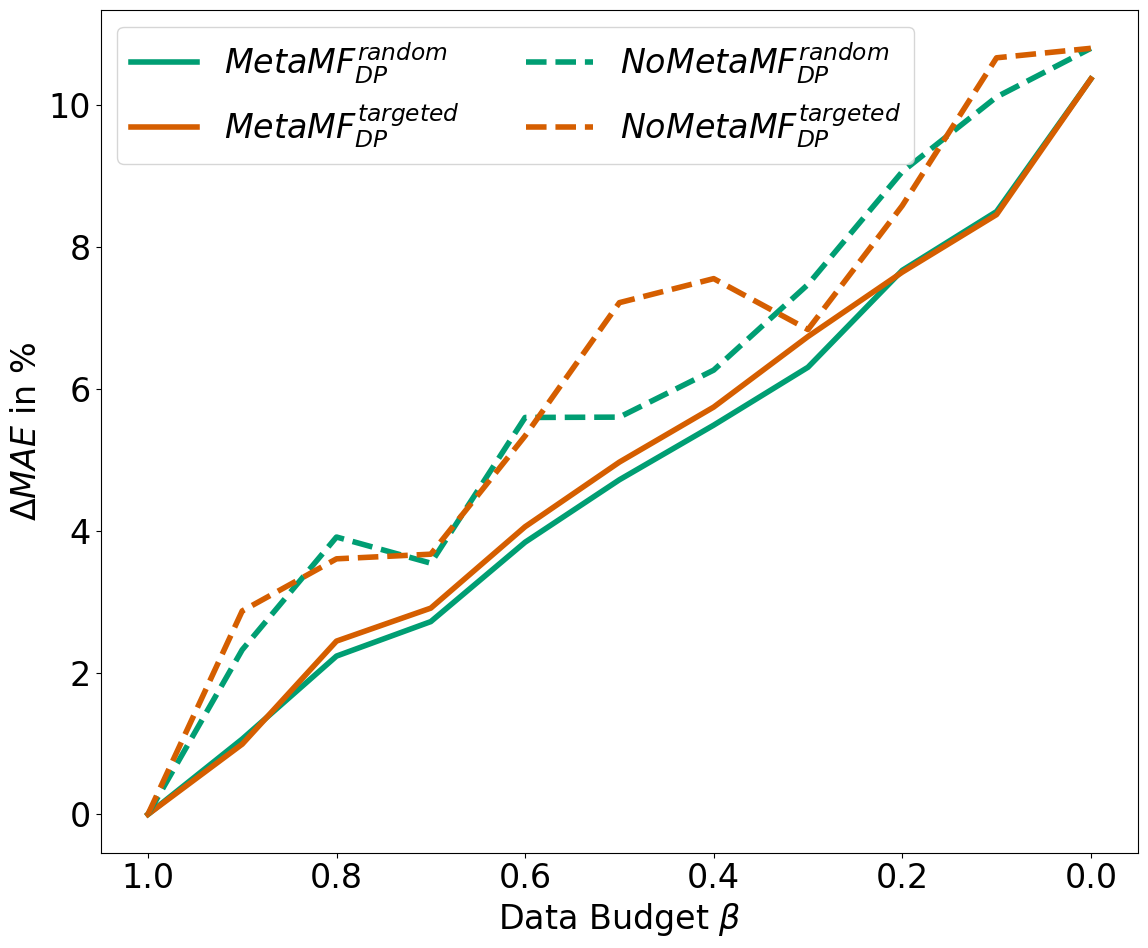

In [69]:
plt.figure(figsize=(12, 10))

meta = ml1m_results_df[ml1m_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
plt.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$MetaMF_{DP}^{random}$", c="C1", linewidth=4)
ister01 = add_baseline(meta, method="ister_dp", e=0.1)
plt.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$MetaMF_{DP}^{targeted}$", c="C2", linewidth=4)

nometa = ml1m_results_df[ml1m_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
plt.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$NoMetaMF_{DP}^{random}$", c="C1", linestyle="dashed", linewidth=4)
ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
plt.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$NoMetaMF_{DP}^{targeted}$", c="C2", linestyle="dashed", linewidth=4)

plt.gca().invert_xaxis()
plt.legend(ncol=2, loc="upper left")
plt.ylabel(r"$\Delta MAE$ in $\%$")
plt.xlabel(r"Data Budget $\beta$")
plt.tight_layout()
plt.savefig("figures/ml1m_sampling.png", dpi=300)

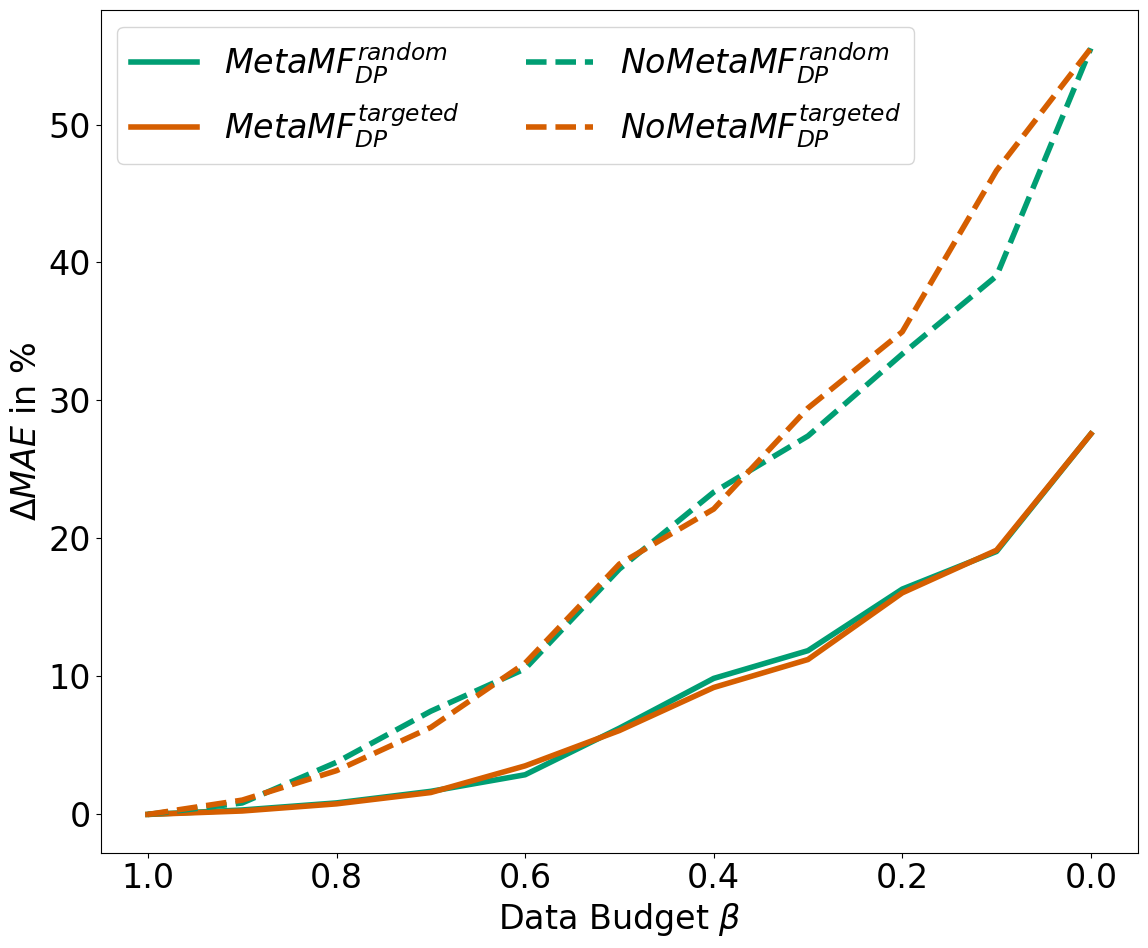

In [70]:
plt.figure(figsize=(12, 10))

meta = bx_results_df[bx_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
plt.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$MetaMF_{DP}^{random}$", c="C1", linewidth=4)
ister01 = add_baseline(meta, method="ister_dp", e=0.1)
plt.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$MetaMF_{DP}^{targeted}$", c="C2", linewidth=4)

nometa = bx_results_df[bx_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
plt.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$NoMetaMF_{DP}^{random}$", c="C1", linestyle="dashed", linewidth=4)
ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
plt.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp, label=r"$NoMetaMF_{DP}^{targeted}$", c="C2", linestyle="dashed", linewidth=4)

plt.gca().invert_xaxis()
plt.legend(ncol=2, loc="upper left")
plt.ylabel(r"$\Delta MAE$ in $\%$")
plt.xlabel(r"Data Budget $\beta$")
plt.tight_layout()
plt.savefig("figures/bx_sampling.png", dpi=300)

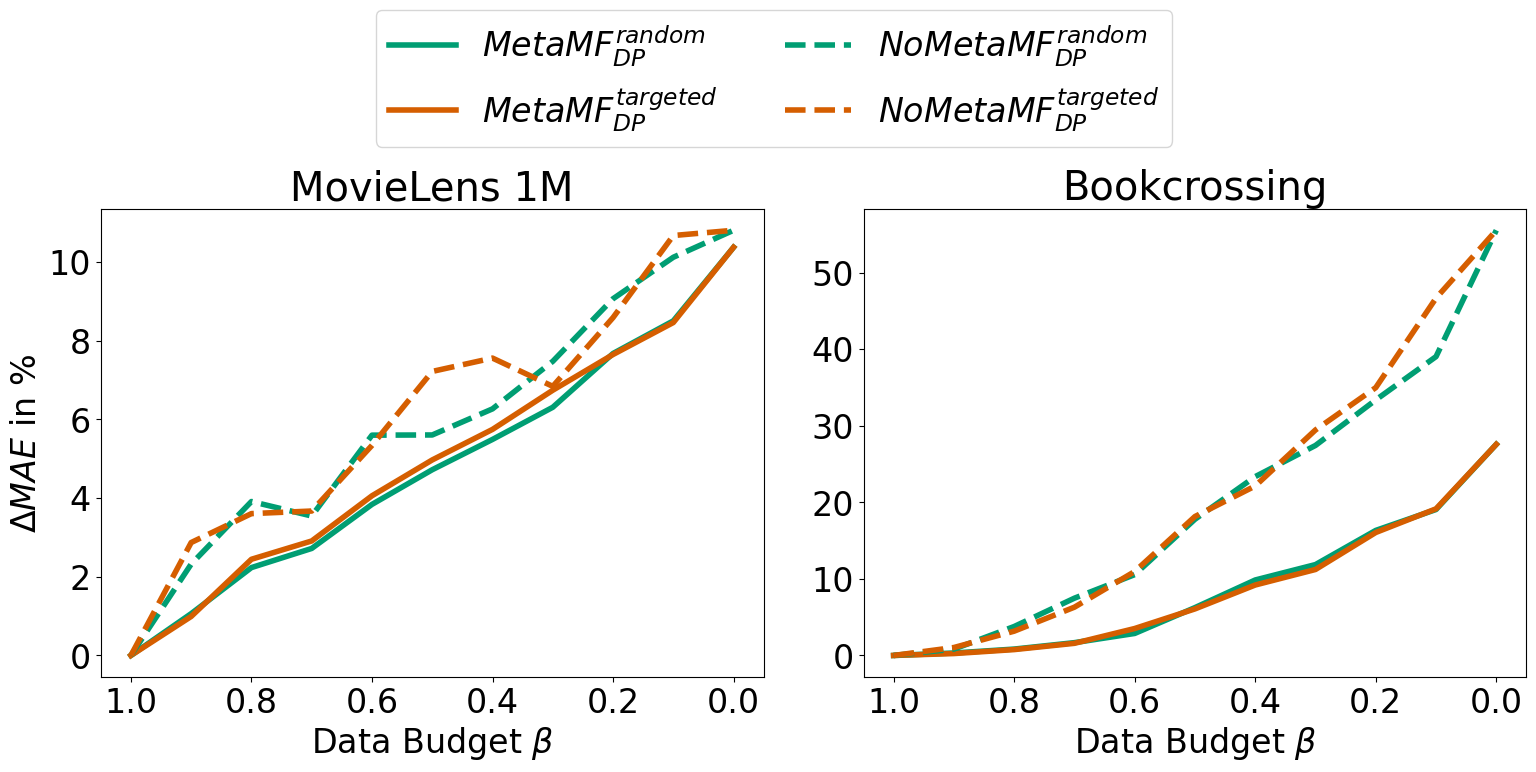

In [83]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ------------------ LEFT: ML1M ------------------
ax = axes[0]

meta = ml1m_results_df[ml1m_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
l1, = ax.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp,
              label=r"$MetaMF_{DP}^{random}$", c="C1", linewidth=4)

ister01 = add_baseline(meta, method="ister_dp", e=0.1)
l2, = ax.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp,
              label=r"$MetaMF_{DP}^{targeted}$", c="C2", linewidth=4)

nometa = ml1m_results_df[ml1m_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
l3, = ax.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp,
              label=r"$NoMetaMF_{DP}^{random}$", c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
l4, = ax.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp,
              label=r"$NoMetaMF_{DP}^{targeted}$", c="C2", linestyle="dashed", linewidth=4)

ax.invert_xaxis()
ax.set_title("MovieLens 1M")
ax.set_xlabel(r"Data Budget $\beta$")
ax.set_ylabel(r"$\Delta MAE$ in $\%$")


# ------------------ RIGHT: BX ------------------
ax = axes[1]

meta = bx_results_df[bx_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
ax.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp,
        c="C1", linewidth=4)

ister01 = add_baseline(meta, method="ister_dp", e=0.1)
ax.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp,
        c="C2", linewidth=4)

nometa = bx_results_df[bx_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
bsl_nodp = random01[random01["b"] == 1.0]["test_mae"].values
ax.plot(random01["b"], 100*(random01["test_mae"] - bsl_nodp) / bsl_nodp,
        c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
ax.plot(ister01["b"], 100*(ister01["test_mae"] - bsl_nodp) / bsl_nodp,
        c="C2", linestyle="dashed", linewidth=4)

ax.invert_xaxis()
ax.set_title("Bookcrossing")
ax.set_xlabel(r"Data Budget $\beta$")


# ------------------ SHARED LEGEND ------------------
fig.legend([l1, l2, l3, l4],
           [l.get_label() for l in [l1, l2, l3, l4]],
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.15))

# leave space for legend
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("figures/combined_sampling.png", dpi=300, bbox_inches="tight")
plt.show()

## absolute values

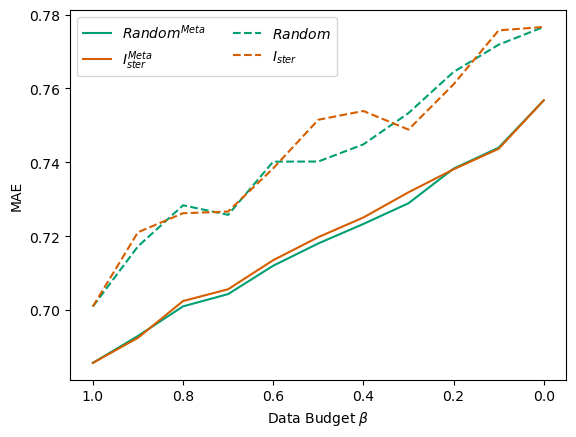

In [48]:
meta = ml1m_results_df[ml1m_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
plt.plot(random01["b"], random01["test_mae"], label=r"$Random^{Meta}$", c="C1")
ister01 = add_baseline(meta, method="ister_dp", e=0.1)
plt.plot(ister01["b"], ister01["test_mae"], label=r"$I_{ster}^{Meta}$", c="C2")

nometa = ml1m_results_df[ml1m_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
plt.plot(random01["b"], random01["test_mae"], label=r"$Random$", c="C1", linestyle="dashed")

ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
plt.plot(ister01["b"], ister01["test_mae"], label=r"$I_{ster}$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel(r"Data Budget $\beta$")
plt.show()

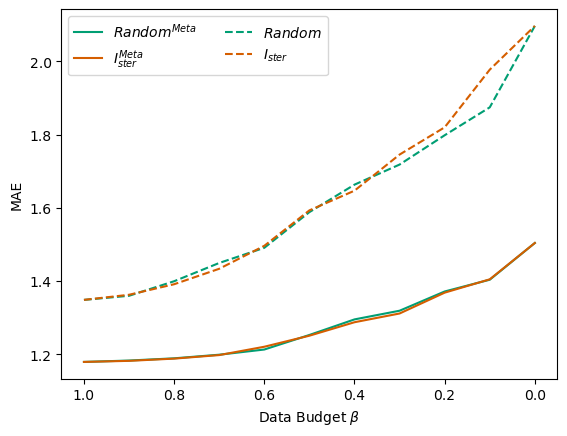

In [49]:
meta = bx_results_df[bx_results_df["recsys"] == "MetaMF"]
random01 = add_baseline(meta, method="random_dp", e=0.1)
plt.plot(random01["b"], random01["test_mae"], label=r"$Random^{Meta}$", c="C1")
ister01 = add_baseline(meta, method="ister_dp", e=0.1)
plt.plot(ister01["b"], ister01["test_mae"], label=r"$I_{ster}^{Meta}$", c="C2")

nometa = bx_results_df[bx_results_df["recsys"] == "NoMetaMF"]
random01 = add_baseline(nometa, method="random_dp", e=0.1)
plt.plot(random01["b"], random01["test_mae"], label=r"$Random$", c="C1", linestyle="dashed")

ister01 = add_baseline(nometa, method="ister_dp", e=0.1)
plt.plot(ister01["b"], ister01["test_mae"], label=r"$I_{ster}$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel(r"Data Budget $\beta$")
plt.show()